In [1]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical,plot_model
import os

In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
label_encoder.fit(["angry","disgust","fear","happy","neutral","sad","surprise"])
data=[]
labels=[]

for emotion_folder in ["angry","disgust","fear","happy","neutral","sad","surprise"]:
    class_index=label_encoder.transform([emotion_folder])[0]
    class_label=to_categorical(class_index,num_classes=7)
    paths=[]
    for r,d,f in os.walk(os.path.join(r"C:\Users\raich\Desktop\emotion detection project\train",emotion_folder)):
        for file in f:
            if file.lower().endswith(('.jpg','.jpeg','.png')):
                paths.append(os.path.join(r,file))

    for path in paths:
        img = Image.open(path).convert("RGB")
        img = img.resize((128,128))
        img = np.array(img)

        if img.shape == (128,128,3):
            data.append(img)
            labels.append(class_label)
data=np.array(data)
labels=np.array(labels)

print(data.shape)
print(labels.shape)

(28709, 128, 128, 3)
(28709, 7)


In [9]:
data=np.array(data)
data.shape

(28709, 128, 128, 3)

In [10]:
result=np.array(labels)
result=result.reshape(28709,-1)
result

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(28709, 7))

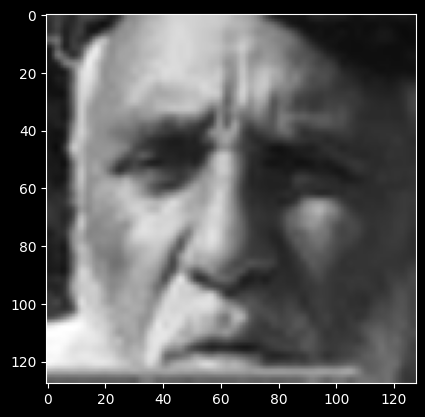

In [11]:
plt.imshow(data[190])

In [12]:
xtrain,xtest,ytrain,ytest=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=42)

In [13]:
output_classes=7
model=Sequential()

model.add(Conv2D(32,kernel_size=(2,2),input_shape=(128,128,3),padding='Same'))
model.add(Conv2D(32,kernel_size=(2,2),activation='relu',padding='Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7,activation='softmax'))

print(model.summary())

C:\Users\raich\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,588,167 (128.13 MB)

 Trainable params: 33,587,975 (128.13 MB)

 Non-trainable params: 192 (768.00 B)

None


In [14]:
model.compile(loss="categorical_crossentropy",optimizer='Adam',metrics=['accuracy'])

In [15]:
xtrain.shape

(22967, 128, 128, 3)

In [16]:
ytrain.shape

(22967, 7)

In [12]:
history=model.fit(xtrain,ytrain,epochs=10,batch_size=20,verbose=1,validation_data=(xtest,ytest))

Epoch 1/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 400s 346ms/step - accuracy: 0.2444 - loss: 2.3222 - val_accuracy: 0.1468 - val_loss: 2.4161
Epoch 2/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 455s 396ms/step - accuracy: 0.2501 - loss: 1.7994 - val_accuracy: 0.2219 - val_loss: 2.1582
Epoch 3/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 444s 387ms/step - accuracy: 0.2518 - loss: 1.7816 - val_accuracy: 0.2564 - val_loss: 1.8011
Epoch 4/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 445s 388ms/step - accuracy: 0.2524 - loss: 1.7760 - val_accuracy: 0.2647 - val_loss: 1.7820
Epoch 5/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 445s 387ms/step - accuracy: 0.2521 - loss: 1.7691 - val_accuracy: 0.2687 - val_loss: 1.7863
Epoch 6/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 445s 387ms/step - accuracy: 0.2535 - loss: 1.7538 - val_accuracy: 0.2614 - val_loss: 1.7561
Epoch 7/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 444s 387ms/step - accuracy: 0.2541 - loss: 1.7567 - val_accuracy: 0.2591 - val_loss: 1.7263
Epoch 8/10
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 451s 392ms/step - ac

In [17]:
test_loss,test_accuracy=model.evaluate(xtest,ytest)
print("Test Accuracy:",test_accuracy*100)

180/180 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.1520 - loss: 15.1861
Test Accuracy: 15.20376205444336


In [18]:
def names(number):
    if number==0:
        return "surprised"
    elif number==1:
        return "sad"
    elif number==2:
        return "neutral"
    elif number==3:
        return "happy"
    elif number==4:
        return "fearful"
    elif number==5:
        return "disgusted"
    else:
        return "angry"

93.242744% Confidence This is happy


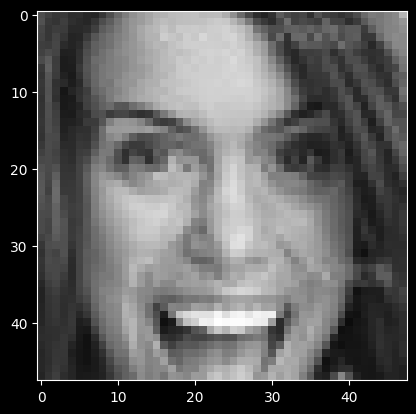

In [25]:
from matplotlib.pyplot import imshow
img = Image.open(r"C:\Users\raich\Desktop\emotion detection project\train\happy\Training_99338865.jpg")
img = img.convert('RGB')
x = np.array(img.resize((128, 128)))
x = x.reshape(-1, 128, 128, 3) 
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification] * 100) + '% Confidence This is ' + names(classification))

In [26]:
model.save("emotion_model.h5")